In [ ]:
# 1. Khai báo các thư viện cần thiết cho việc xử lý dữ liệu
import pandas as pd
import numpy as np
from google.colab import files
import io

print("Đang khởi tạo môi trường và nạp thư viện...")

# 2. Tạo giao diện tải tệp dữ liệu (Dataset) từ thiết bị lên Google Colab
print("Vui lòng nhấn nút 'Choose Files' bên dưới để tải tập dữ liệu (CSV/Excel) lên:")
uploaded = files.upload()

# 3. Đọc dữ liệu vào Pandas DataFrame và kiểm tra cấu trúc
if len(uploaded) > 0:
    ten_file = list(uploaded.keys())[0]

    # Hệ thống tự động nhận diện định dạng tệp để xử lý
    if ten_file.endswith('.csv'):
        df = pd.read_csv(io.BytesIO(uploaded[ten_file]))
    else:
        df = pd.read_excel(io.BytesIO(uploaded[ten_file]))

    print(f"\n✅ Đã tải và đọc thành công tệp dữ liệu: {ten_file}")
    print(f"📊 Kích thước tập dữ liệu: {df.shape[0]} mẫu (dòng) và {df.shape[1]} đặc trưng (cột).")

    print("\nHiển thị 3 mẫu dữ liệu đầu tiên để kiểm tra:")
    display(df.head(3))
else:
    print("\n⚠️ Chưa có tệp nào được tải lên. Vui lòng chạy lại ô lệnh này và chọn tệp dữ liệu.")

Đang khởi tạo môi trường và nạp thư viện...
Vui lòng nhấn nút 'Choose Files' bên dưới để tải tập dữ liệu (CSV/Excel) lên:


Saving Data thô 2934 truyện crawl từ web Wikidich.csv to Data thô 2934 truyện crawl từ web Wikidich.csv

✅ Đã tải và đọc thành công tệp dữ liệu: Data thô 2934 truyện crawl từ web Wikidich.csv
📊 Kích thước tập dữ liệu: 2934 mẫu (dòng) và 9 đặc trưng (cột).

Hiển thị 3 mẫu dữ liệu đầu tiên để kiểm tra:


,Ten_Truyen,Tac_Gia,The_Loai,Tinh_Trang,Luot_Xem,Luot_Sao,Luot_Binh_Luan,Luot_Cam_On,Link
0,"Trọng sinh thiên kim thực phúc hắc: Cố thiếu, ...",Na Thời Yên Hoa,"Nguyên sang , Ngôn tình , Hiện đại , HE , Tình...",Hoàn thành,1079407,254,10,51.0,https://wikicv.net/truyen/trong-sinh-thien-kim...
1,"Kinh thế y phi, phúc hắc Cửu hoàng thúc",Lục Y,"Nguyên sang , Ngôn tình , Cổ đại , HE , Tình c...",Hoàn thành,1078726,15,2,9.0,https://wikicv.net/truyen/kinh-the-y-phi-phuc-...
2,Xuyên qua chi nông phụ thực nương,Nguyệt Bán Yếu Phân Gia,"Nguyên sang , Ngôn tình , Cổ đại , HE , Tình c...",Hoàn thành,1077826,882,69,395.0,https://wikicv.net/truyen/xuyen-qua-chi-nong-p...


In [ ]:
import pandas as pd
from collections import Counter

# Đọc file (đúng tên của chị)
df = pd.read_csv('/content/Data thô 2934 truyện crawl từ web Wikidich.csv')

# Xử lý cột thể loại
df['The_Loai'] = df['The_Loai'].fillna('')

# Tách tag
df['tags'] = df['The_Loai'].apply(
    lambda x: [tag.strip() for tag in str(x).split(',') if tag.strip() != '']
)

# 3 tag cố định
fixed_tags = ['Ngôn tình', 'Đam mỹ', 'Bách hợp']

# Đếm tần suất
all_tags = [tag for tag_list in df['tags'] for tag in tag_list]
tag_counter = Counter(all_tags)

# Chuyển sang DataFrame để xem
tag_freq_df = pd.DataFrame(tag_counter.items(), columns=['Tag', 'So_lan'])
tag_freq_df = tag_freq_df.sort_values(by='So_lan', ascending=False)

print("Top 30 tag:")
print(tag_freq_df.head(30))

# Loại bỏ 3 tag cố định
candidate_tags = tag_freq_df[~tag_freq_df['Tag'].isin(fixed_tags)]

# Lọc tag hiếm (>=30)
candidate_tags = candidate_tags[candidate_tags['So_lan'] >= 30]

# Lấy 17 tag
top_17_tags = candidate_tags.head(17)['Tag'].tolist()

# Tổng 20 tag
selected_tags = fixed_tags + top_17_tags

print("\n20 tag cuối:")
print(selected_tags)
print("Số lượng:", len(selected_tags))

Top 30 tag:
                    Tag  So_lan
3                    HE    2728
4              Tình cảm    2721
0           Nguyên sang    2616
2              Hiện đại    1743
6              Ngọt văn    1415
26                  1v1    1369
14               Cổ đại    1349
15           Xuyên việt    1061
249            Bách hợp     998
1             Ngôn tình     990
321              Đam mỹ     934
21            Nhẹ nhàng     930
257             Chủ thụ     899
43             Sảng văn     893
71      Kim bài đề cử 🥇     703
36             Hệ thống     670
37            Xuyên thư     618
7            Trọng sinh     609
29          Huyền huyễn     603
39      Thị giác nữ chủ     591
19          Cường cường     574
10      Hào môn thế gia     567
8         Song khiết 🕊️     560
49          Xuyên nhanh     514
56            Tương lai     391
258            Chủ công     379
12   Duyên trời tác hợp     375
42        Giới giải trí     366
66              Tu chân     354
52   Cung đình hầu tước     

In [ ]:
import pandas as pd
from collections import Counter

# Đọc file (đúng tên của chị)
df = pd.read_csv('/content/Data thô 2934 truyện crawl từ web Wikidich.csv')

# Xử lý cột thể loại
df['The_Loai'] = df['The_Loai'].fillna('')

# Tách tag
df['tags'] = df['The_Loai'].apply(
    lambda x: [tag.strip() for tag in str(x).split(',') if tag.strip() != '']
)

# =========================
# 3 TAG CỐ ĐỊNH
# =========================
fixed_tags = ['Ngôn tình', 'Đam mỹ', 'Bách hợp']  # nhớ đúng chính tả y hệt data

# =========================
# ĐẾM TẦN SUẤT
# =========================
all_tags = [tag for tag_list in df['tags'] for tag in tag_list]
tag_counter = Counter(all_tags)

# Tạo DataFrame + sort + reset index cho đẹp
tag_freq_df = pd.DataFrame(tag_counter.items(), columns=['Tag', 'So_lan'])
tag_freq_df = tag_freq_df.sort_values(by='So_lan', ascending=False).reset_index(drop=True)

print("Top 20 tag phổ biến:")
print(tag_freq_df.head(20))

# =========================
# LOẠI 3 TAG CỐ ĐỊNH
# =========================
candidate_tags = tag_freq_df[~tag_freq_df['Tag'].isin(fixed_tags)]

# =========================
# LỌC TAG HIẾM (>= 30 lần)
# =========================
candidate_tags = candidate_tags[candidate_tags['So_lan'] >= 30]

# =========================
# LẤY 17 TAG
# =========================
top_17_tags = candidate_tags.head(17)['Tag'].tolist()

# =========================
# GHÉP THÀNH 20 TAG
# =========================
selected_tags = fixed_tags + top_17_tags

# =========================
# IN KẾT QUẢ
# =========================
print("\n3 tag cố định:")
print(fixed_tags)

print("\n17 tag được chọn thêm:")
print(top_17_tags)

print("\n👉 20 TAG CUỐI CÙNG:")
print(selected_tags)

print("\nSố lượng:", len(selected_tags))

Top 20 tag phổ biến:
                Tag  So_lan
0                HE    2728
1          Tình cảm    2721
2       Nguyên sang    2616
3          Hiện đại    1743
4          Ngọt văn    1415
5               1v1    1369
6            Cổ đại    1349
7        Xuyên việt    1061
8          Bách hợp     998
9         Ngôn tình     990
10           Đam mỹ     934
11        Nhẹ nhàng     930
12          Chủ thụ     899
13         Sảng văn     893
14  Kim bài đề cử 🥇     703
15         Hệ thống     670
16        Xuyên thư     618
17       Trọng sinh     609
18      Huyền huyễn     603
19  Thị giác nữ chủ     591

3 tag cố định:
['Ngôn tình', 'Đam mỹ', 'Bách hợp']

17 tag được chọn thêm:
['HE', 'Tình cảm', 'Nguyên sang', 'Hiện đại', 'Ngọt văn', '1v1', 'Cổ đại', 'Xuyên việt', 'Nhẹ nhàng', 'Chủ thụ', 'Sảng văn', 'Kim bài đề cử 🥇', 'Hệ thống', 'Xuyên thư', 'Trọng sinh', 'Huyền huyễn', 'Thị giác nữ chủ']

👉 20 TAG CUỐI CÙNG:
['Ngôn tình', 'Đam mỹ', 'Bách hợp', 'HE', 'Tình cảm', 'Nguyên sang', 'Hiện đạ

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

# =========================
# 1. ĐỌC FILE
# =========================
file_path = '/content/Data thô 2934 truyện crawl từ web Wikidich.csv'
df = pd.read_csv(file_path)

print("Kích thước dữ liệu ban đầu:", df.shape)
print("Tên cột:")
print(df.columns.tolist())

# =========================
# 2. HÀM TÌM TÊN CỘT GẦN ĐÚNG
# =========================
def find_col(possible_names, columns):
    for name in possible_names:
        if name in columns:
            return name
    return None

# Tìm các cột quan trọng theo nhiều khả năng tên khác nhau
col_title = find_col(['Ten_Truyen', 'Tên truyện', 'Ten truyen', 'Title'], df.columns)
col_author = find_col(['Tac_Gia', 'Tác giả', 'Tac gia', 'Author'], df.columns)
col_tags = find_col(['The_Loai', 'Thể loại', 'The loai', 'Tags'], df.columns)
col_status = find_col(['Tinh_Trang', 'Tình trạng', 'Tinh trang', 'Status'], df.columns)

col_view = find_col(['Luot_Xem', 'Lượt xem', 'Luot xem', 'View'], df.columns)
col_star = find_col(['Luot_Sao', 'Lượt sao', 'Luot sao', 'Star'], df.columns)
col_cmt = find_col(['Binh_Luan', 'Bình luận', 'Binh luan', 'Luot_Binh_Luan', 'Comments'], df.columns)
col_like = find_col(['Luot_Cam', 'Lượt cảm', 'Luot cam', 'Luot_Cam_On', 'Like'], df.columns)
col_link = find_col(['Link', 'link', 'URL', 'Url'], df.columns)

print("\nCác cột được nhận diện:")
print("Title:", col_title)
print("Author:", col_author)
print("Tags:", col_tags)
print("Status:", col_status)
print("View:", col_view)
print("Star:", col_star)
print("Comment:", col_cmt)
print("Like:", col_like)
print("Link:", col_link)

# =========================
# 3. LÀM SẠCH CÁC CỘT SỐ
#    lỗi / trống / ### => 0
# =========================
numeric_cols = [c for c in [col_view, col_star, col_cmt, col_like] if c is not None]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('.', '', regex=False)   # nếu dữ liệu có dấu chấm ngăn cách hàng nghìn
        .str.replace('###', '', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print("\nĐã làm sạch cột số xong.")
print(df[numeric_cols].head())

# =========================
# 4. LÀM SẠCH CỘT TAG & TÌNH TRẠNG
#    ô trống => ''
# =========================
if col_tags is None:
    raise ValueError("Không tìm thấy cột thể loại.")
if col_status is None:
    raise ValueError("Không tìm thấy cột tình trạng.")

df[col_tags] = df[col_tags].fillna('').astype(str).str.strip()
df[col_status] = df[col_status].fillna('').astype(str).str.strip()

# =========================
# 5. TÁCH TAG
# =========================
df['tags'] = df[col_tags].apply(
    lambda x: [tag.strip() for tag in str(x).split(',') if tag.strip() != '']
)

# =========================
# 6. CHỌN 20 TAG
#    - 3 tag cố định
#    - 17 tag phổ biến còn lại
# =========================
fixed_tags = ['Ngôn tình', 'Đam mỹ', 'Bách hợp']

all_tags = [tag for tag_list in df['tags'] for tag in tag_list]
tag_counter = Counter(all_tags)

tag_freq_df = pd.DataFrame(tag_counter.items(), columns=['Tag', 'So_lan'])
tag_freq_df = tag_freq_df.sort_values(by='So_lan', ascending=False).reset_index(drop=True)

# Loại 3 tag cố định
candidate_tags = tag_freq_df[~tag_freq_df['Tag'].isin(fixed_tags)]

# Lọc tag hiếm: >= 30 lần
candidate_tags = candidate_tags[candidate_tags['So_lan'] >= 30]

# Lấy 17 tag phổ biến nhất còn lại
top_17_tags = candidate_tags.head(17)['Tag'].tolist()

selected_tags = fixed_tags + top_17_tags

print("\n3 tag cố định:", fixed_tags)
print("\n17 tag thêm:", top_17_tags)
print("\n20 tag cuối cùng:", selected_tags)
print("Số lượng tag:", len(selected_tags))

# =========================
# 7. ENCODE TAG
# =========================
for tag in selected_tags:
    safe_tag = tag.replace(' ', '_').replace('/', '_')
    df[f'tag_{safe_tag}'] = df['tags'].apply(lambda x: 1 if tag in x else 0)

# =========================
# 8. ENCODE TÌNH TRẠNG
#    giữ toàn bộ trạng thái có trong data
# =========================
status_list = sorted([s for s in df[col_status].dropna().unique().tolist() if s != ''])

print("\nCác tình trạng trong dữ liệu:")
print(status_list)
print("Số lượng tình trạng:", len(status_list))

for status in status_list:
    safe_status = status.replace(' ', '_').replace('/', '_')
    df[f'tt_{safe_status}'] = df[col_status].apply(lambda x: 1 if x == status else 0)

# =========================
# 9. TẠO MA TRẬN X
# =========================
tag_feature_cols = [f"tag_{tag.replace(' ', '_').replace('/', '_')}" for tag in selected_tags]
status_feature_cols = [f"tt_{status.replace(' ', '_').replace('/', '_')}" for status in status_list]

feature_cols = tag_feature_cols + status_feature_cols
X = df[feature_cols].copy()

print("\nShape của X:", X.shape)
print(X.head())

# =========================
# 10. TẠO FILE EXCEL XUẤT RA
# =========================
# File 1: dữ liệu đầy đủ sau xử lý
output_full = '/content/data_da_xu_ly_day_du.xlsx'
df.to_excel(output_full, index=False)

# File 2: chỉ ma trận X
output_X = '/content/X_features.xlsx'
X.to_excel(output_X, index=False)

# File 3: bảng tần suất tag
output_tagfreq = '/content/tan_suat_tag.xlsx'
tag_freq_df.to_excel(output_tagfreq, index=False)

print("\nĐã xuất file:")
print(output_full)
print(output_X)
print(output_tagfreq)

Kích thước dữ liệu ban đầu: (2934, 9)
Tên cột:
['Ten_Truyen', 'Tac_Gia', 'The_Loai', 'Tinh_Trang', 'Luot_Xem', 'Luot_Sao', 'Luot_Binh_Luan', 'Luot_Cam_On', 'Link']

Các cột được nhận diện:
Title: Ten_Truyen
Author: Tac_Gia
Tags: The_Loai
Status: Tinh_Trang
View: Luot_Xem
Star: Luot_Sao
Comment: Luot_Binh_Luan
Like: Luot_Cam_On
Link: Link

Đã làm sạch cột số xong.
   Luot_Xem  Luot_Sao  Luot_Binh_Luan  Luot_Cam_On
0   1079407       254              10        510.0
1   1078726        15               2         90.0
2   1077826       882              69       3950.0
3   1076750      7055              47       5450.0
4   1076582      1595              41       2010.0

3 tag cố định: ['Ngôn tình', 'Đam mỹ', 'Bách hợp']

17 tag thêm: ['HE', 'Tình cảm', 'Nguyên sang', 'Hiện đại', 'Ngọt văn', '1v1', 'Cổ đại', 'Xuyên việt', 'Nhẹ nhàng', 'Chủ thụ', 'Sảng văn', 'Kim bài đề cử 🥇', 'Hệ thống', 'Xuyên thư', 'Trọng sinh', 'Huyền huyễn', 'Thị giác nữ chủ']

20 tag cuối cùng: ['Ngôn tình', 'Đam mỹ', 'B

In [ ]:
print("Shape X:", X.shape)
print("Số cột tag:", len(tag_feature_cols))
print("Số cột tình trạng:", len(status_feature_cols))

Shape X: (2934, 25)
Số cột tag: 20
Số cột tình trạng: 5


In [ ]:
from google.colab import files

files.download('/content/data_da_xu_ly_day_du.xlsx')
files.download('/content/X_features.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# =========================
# FIX CỘT CHO CHẮC
# =========================
col_view = 'Luot_Xem'
col_star = 'Luot_Sao'
col_cmt  = 'Luot_Binh_Luan'

# =========================
# LẤY DỮ LIỆU
# =========================
view = df[col_view]
star = df[col_star]
cmt  = df[col_cmt]

# =========================
# LOG TRANSFORM
# =========================
view_log = np.log1p(view)
star_log = np.log1p(star)
cmt_log  = np.log1p(cmt)

# =========================
# SCALE 0-1
# =========================
scaler = MinMaxScaler()
scaled = scaler.fit_transform(
    np.vstack([view_log, star_log, cmt_log]).T
)

view_s = scaled[:, 0]
star_s = scaled[:, 1]
cmt_s  = scaled[:, 2]

# =========================
# TẠO Y
# =========================
df['Y'] = 0.4 * star_s + 0.35 * cmt_s + 0.25 * view_s

# =========================
# CHECK
# =========================
print("OK rồi nhé ")
print(df[['Y']].head())
print(df['Y'].describe())

OK rồi nhé 
          Y
0  0.473575
1  0.330458
2  0.588983
3  0.641734
4  0.587695
count    2934.000000
mean        0.577056
std         0.119920
min         0.000000
25%         0.489624
50%         0.586237
75%         0.660016
max         0.983049
Name: Y, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    df['Y'],
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2347, 25)
X_test : (587, 25)
y_train: (2347,)
y_test : (587,)


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

In [ ]:
model = Lasso(alpha=0.001)
print(model)

Lasso(alpha=0.001)


In [ ]:
model.fit(X_train, y_train)
print("Train xong rồi")

Train xong rồi


In [ ]:
y_pred = model.predict(X_test)

print("5 giá trị dự đoán đầu:")
print(y_pred[:5])

5 giá trị dự đoán đầu:
[0.64093453 0.66329223 0.68005944 0.5415749  0.45318476]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 =", r2)

MAE = 0.059492153357032694
MSE = 0.0060586442171807475
RMSE = 0.07783729322876501
R2 = 0.5497812390023259


In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_
})

coef_df = coef_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print(coef_df)

                Feature    Weight
0            tag_Đam_mỹ  0.117393
1   tag_Thị_giác_nữ_chủ  0.055307
2         tag_Ngôn_tình  0.053104
3          tag_Hệ_thống  0.039623
4   tag_Kim_bài_đề_cử_🥇  0.033586
5       tag_Huyền_huyễn  0.023573
6         tag_Xuyên_thư  0.018421
7            tag_Cổ_đại  0.017775
8               tag_1v1  0.010748
9          tag_Hiện_đại  0.009263
10         tag_Sảng_văn  0.008524
11        tag_Nhẹ_nhàng  0.004582
12       tag_Xuyên_việt  0.000000
13               tag_HE -0.000000
14         tag_Ngọt_văn -0.000000
15         tag_Tình_cảm  0.000000
16      tag_Nguyên_sang  0.000000
17          tt_Còn_tiếp  0.000000
18          tag_Chủ_thụ  0.000000
19       tag_Trọng_sinh -0.000000
20     tt_Chưa_xác_minh  0.000000
21         tt_Tạm_ngưng  0.000000
22        tt_Hoàn_thành  0.000000
23         tag_Bách_hợp -0.048380
24     tt_Đang_cập_nhật -0.244507


In [ ]:
print("Top 10 feature ảnh hưởng dương mạnh nhất:")
print(coef_df.head(10))

print("\n10 feature thấp nhất:")
print(coef_df.tail(10))

Top 10 feature ảnh hưởng dương mạnh nhất:
               Feature    Weight
0           tag_Đam_mỹ  0.117393
1  tag_Thị_giác_nữ_chủ  0.055307
2        tag_Ngôn_tình  0.053104
3         tag_Hệ_thống  0.039623
4  tag_Kim_bài_đề_cử_🥇  0.033586
5      tag_Huyền_huyễn  0.023573
6        tag_Xuyên_thư  0.018421
7           tag_Cổ_đại  0.017775
8              tag_1v1  0.010748
9         tag_Hiện_đại  0.009263

10 feature thấp nhất:
             Feature    Weight
15      tag_Tình_cảm  0.000000
16   tag_Nguyên_sang  0.000000
17       tt_Còn_tiếp  0.000000
18       tag_Chủ_thụ  0.000000
19    tag_Trọng_sinh -0.000000
20  tt_Chưa_xác_minh  0.000000
21      tt_Tạm_ngưng  0.000000
22     tt_Hoàn_thành  0.000000
23      tag_Bách_hợp -0.048380
24  tt_Đang_cập_nhật -0.244507


In [ ]:
num_zero = (coef_df['Weight'] == 0).sum()
num_nonzero = (coef_df['Weight'] != 0).sum()

print("Số feature bị ép về 0:", num_zero)
print("Số feature còn được giữ:", num_nonzero)

Số feature bị ép về 0: 11
Số feature còn được giữ: 14


In [ ]:
coef_df.to_excel('/content/trong_so_lasso.xlsx', index=False)

from google.colab import files
files.download('/content/trong_so_lasso.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

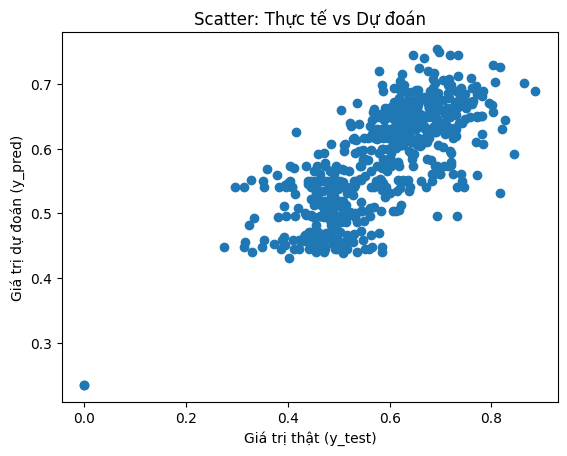

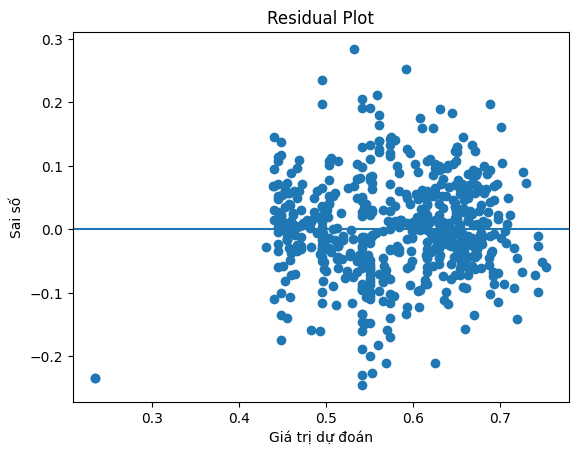

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


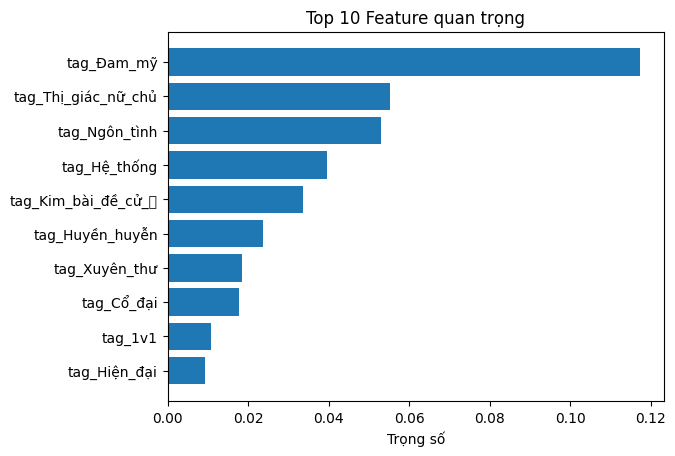

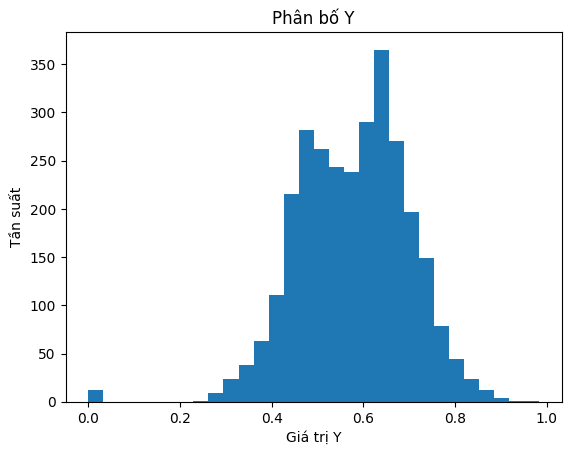

In [ ]:
import matplotlib.pyplot as plt

# =========================
# 1. Scatter: y_test vs y_pred
# =========================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Giá trị thật (y_test)")
plt.ylabel("Giá trị dự đoán (y_pred)")
plt.title("Scatter: Thực tế vs Dự đoán")
plt.show()


# =========================
# 2. Residual Plot
# =========================
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Giá trị dự đoán")
plt.ylabel("Sai số")
plt.title("Residual Plot")
plt.show()


# =========================
# 3. Top 10 Feature quan trọng
# =========================
top10 = coef_df.head(10)

plt.figure()
plt.barh(top10['Feature'], top10['Weight'])
plt.xlabel("Trọng số")
plt.title("Top 10 Feature quan trọng")
plt.gca().invert_yaxis()
plt.show()


# =========================
# 4. Phân bố Y
# =========================
plt.figure()
plt.hist(df['Y'], bins=30)
plt.title("Phân bố Y")
plt.xlabel("Giá trị Y")
plt.ylabel("Tần suất")
plt.show()

In [ ]:
alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01]

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    print(f"alpha = {a} → R2 = {r2}")

alpha = 0.0001 → R2 = 0.5685458524376379
alpha = 0.0005 → R2 = 0.5616938876466684
alpha = 0.001 → R2 = 0.5497812390023259
alpha = 0.005 → R2 = 0.4382017277791729
alpha = 0.01 → R2 = 0.3310291016963901


In [ ]:
model = Lasso(alpha=0.0001)
model.fit(X_train, y_train)

Lasso(alpha=0.0001)

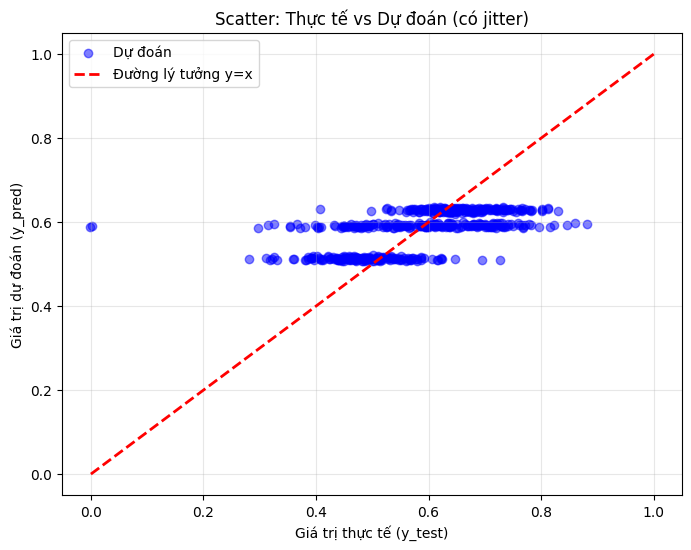

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# chuyển về array cho chắc
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)

# thêm nhiễu rất nhỏ để các điểm không đè lên nhau
jitter_x = np.random.normal(0, 0.005, size=len(y_test_arr))
jitter_y = np.random.normal(0, 0.002, size=len(y_pred_arr))

plt.figure(figsize=(8,6))
plt.scatter(y_test_arr + jitter_x, y_pred_arr + jitter_y, alpha=0.5, color='blue', label='Dự đoán')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng y=x')

plt.xlabel("Giá trị thực tế (y_test)")
plt.ylabel("Giá trị dự đoán (y_pred)")
plt.title("Scatter: Thực tế vs Dự đoán (có jitter)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

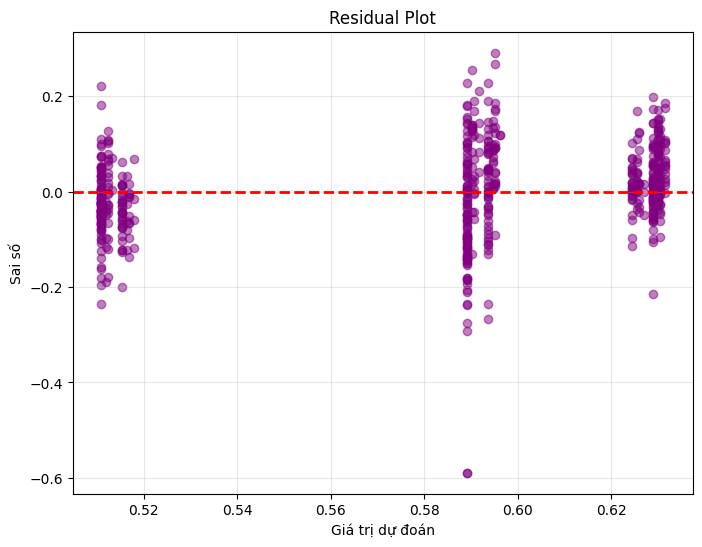

In [ ]:
residuals = y_test_arr - y_pred_arr

plt.figure(figsize=(8,6))
plt.scatter(y_pred_arr, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Giá trị dự đoán")
plt.ylabel("Sai số")
plt.title("Residual Plot")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 =", r2)

MAE = 0.05901164861069805
MSE = 0.0058086664968074
RMSE = 0.07621460815885234
R2 = 0.568357120917353


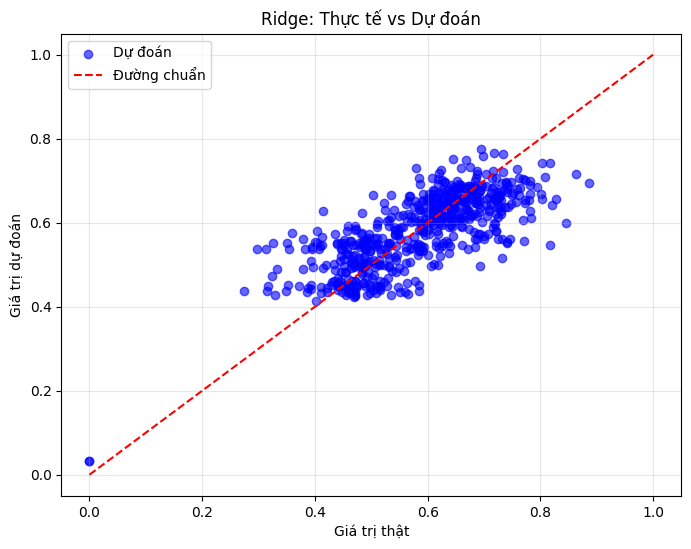

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Dự đoán')

plt.plot([0,1], [0,1], color='red', linestyle='--', label='Đường chuẩn')

plt.xlabel("Giá trị thật")
plt.ylabel("Giá trị dự đoán")
plt.title("Ridge: Thực tế vs Dự đoán")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
from sklearn.linear_model import Lasso

# Khởi tạo và train mô hình Lasso
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train, y_train)

# Dự đoán giá trị
y_pred_lasso = lasso_model.predict(X_test)

# Tính R² cho Lasso
r2_lasso = r2_score(y_test, y_pred_lasso)

In [ ]:
# Hiển thị R2 của Lasso và Ridge
print("Lasso R2:", r2_lasso)
print("Ridge R2:", r2)

Lasso R2: 0.5497812390023259
Ridge R2: 0.568357120917353


Đang xử lý ngoại lai + train lại model...
R2:   0.5689
MAE:  0.0892
RMSE: 0.1170


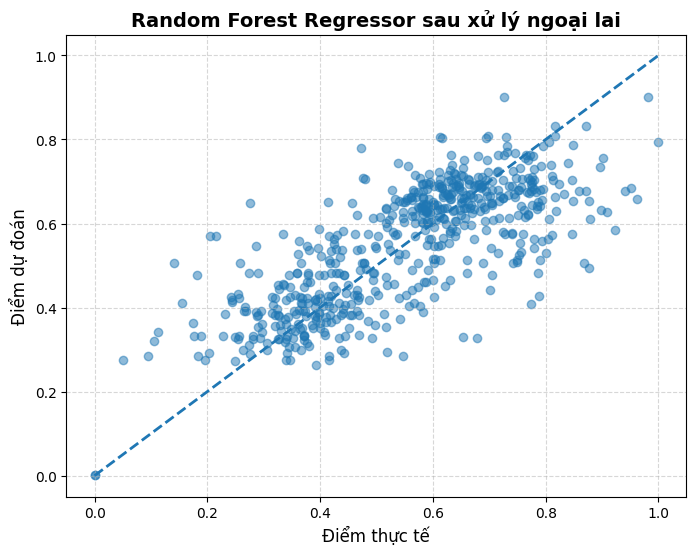

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Đang xử lý ngoại lai + train lại model...")

# =========================
# 1. TẠO BẢN SAO DF
# =========================
df_clean = df.copy()

# Nếu X chưa có thì tự lấy các cột tag_
if 'X' not in globals():
    tag_cols = [col for col in df_clean.columns if col.startswith('tag_')]
    X = df_clean[tag_cols].fillna(0)

# =========================
# 2. HÀM CHẶN NGOẠI LAI THEO PERCENTILE
# =========================
def cap_outliers(series, lower=0.01, upper=0.99):
    low = series.quantile(lower)
    high = series.quantile(upper)
    return series.clip(lower=low, upper=high)

# Chặn ngoại lai ở 3 cột chính
df_clean['Luot_Xem_cap'] = cap_outliers(df_clean['Luot_Xem'].fillna(0))
df_clean['Luot_Binh_Luan_cap'] = cap_outliers(df_clean['Luot_Binh_Luan'].fillna(0))
df_clean['Luot_Sao_cap'] = cap_outliers(df_clean['Luot_Sao'].fillna(0))

# =========================
# 3. LOG TRANSFORM CHO MƯỢT HƠN
# =========================
df_clean['View_log'] = np.log1p(df_clean['Luot_Xem_cap'])
df_clean['Cmt_log'] = np.log1p(df_clean['Luot_Binh_Luan_cap'])
df_clean['Star_log'] = np.log1p(df_clean['Luot_Sao_cap'])

# =========================
# 4. CHUẨN HÓA
# =========================
scaler = MinMaxScaler()
df_clean[['View_norm', 'Cmt_norm', 'Star_norm']] = scaler.fit_transform(
    df_clean[['View_log', 'Cmt_log', 'Star_log']]
)

# =========================
# 5. TÍNH y
# =========================
y = (
    0.5 * df_clean['Star_norm'] +
    0.3 * df_clean['Cmt_norm'] +
    0.2 * df_clean['View_norm']
)

# =========================
# 6. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 7. RANDOM FOREST ĐỠ GẮT HƠN
# =========================
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# =========================
# 8. ĐÁNH GIÁ
# =========================
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"R2:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# =========================
# 9. VẼ BIỂU ĐỒ ĐẸP HƠN
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)

# Đường lý tưởng y = x
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=2)

plt.title('Random Forest Regressor sau xử lý ngoại lai', fontsize=14, fontweight='bold')
plt.xlabel('Điểm thực tế', fontsize=12)
plt.ylabel('Điểm dự đoán', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr

print("1. Đang tải dữ liệu Đặc trưng (Tags)...")
# Lấy các cột Tag làm đặc trưng (X)
cot_dac_trung = [col for col in df.columns if col.startswith('tag_')]
X = df[cot_dac_trung]

print("2. Khởi tạo Giao diện Web App Hồng - Xanh lá...")
danh_sach_tag_goc = list(X.columns)
danh_sach_hien_thi = [tag.replace('tag_', '').replace('_', ' ') for tag in danh_sach_tag_goc]

# Hàm cốt lõi: TẬP TRUNG HOÀN TOÀN VÀO VIỆC TÌM TRUYỆN, BỎ MỌI LOẠI ĐIỂM
def he_thong_goi_y(cac_tag_da_chon):
    if not cac_tag_da_chon:
        return "❌ Chị vui lòng tích chọn ít nhất 1 thể loại nhé!"

    # Tạo vector từ người dùng
    input_vector = np.zeros(len(danh_sach_tag_goc))
    for tag_dep in cac_tag_da_chon:
        idx = danh_sach_hien_thi.index(tag_dep)
        input_vector[idx] = 1

    input_vector = input_vector.reshape(1, -1)

    # Tìm truyện thực tế bằng Cosine Similarity
    sim_scores = cosine_similarity(input_vector, X)[0]
    top_5_idx = sim_scores.argsort()[-5:][::-1]

    # --- TRÌNH BÀY KẾT QUẢ SẠCH SẼ, HIỆN ĐẠI ---
    ket_qua = "📚 CÓ THỂ BẠN SẼ THÍCH NHỮNG BỘ TRUYỆN SAU:\n"
    ket_qua += "➖" * 20 + "\n\n"

    for rank, i in enumerate(top_5_idx, 1):
        ten = df.iloc[i]['Ten_Truyen']
        the_loai = df.iloc[i]['The_Loai']
        link = df.iloc[i]['Link']

        # Chỉ in ra Tên, Thể loại và Link. Tuyệt đối không in điểm!
        ket_qua += f"{rank}. {ten}\n"
        ket_qua += f"   🏷️ Thể loại: {the_loai}\n"
        ket_qua += f"   🔗 Link đọc: {link}\n\n"

    return ket_qua

# Gán màu sắc Giao diện
custom_theme = gr.themes.Default(
    primary_hue="pink",      # Màu hồng chủ đạo
    secondary_hue="emerald"  # Xanh lá điểm nhấn
)

# Thiết kế Giao diện
giao_dien = gr.Interface(
    fn=he_thong_goi_y,
    inputs=gr.CheckboxGroup(choices=danh_sach_hien_thi, label="BỘ LỌC SỞ THÍCH CỦA BẠN (Có thể chọn nhiều):"),
    outputs=gr.Textbox(label="KẾT QUẢ GỢI Ý TỪ HỆ THỐNG", lines=15),
    title="✨ AI RECOMMENDER SYSTEM: HỆ THỐNG GỢI Ý TRUYỆN ✨",
    description="Vui lòng tích chọn các thể loại bạn yêu thích. Hệ thống sẽ phân tích và tìm ra 5 bộ truyện phù hợp nhất dành riêng cho bạn.",
    theme=custom_theme
)

# Chạy Web App
print("Hoàn tất! Đang tạo Link Web...")
giao_dien.launch(share=True, inline=False)

1. Đang tải dữ liệu Đặc trưng (Tags)...
2. Khởi tạo Giao diện Web App Hồng - Xanh lá...
Hoàn tất! Đang tạo Link Web...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://40a9c8a0a0d80ac94a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
